# Week 8 · Day 2 — Assignment
# Model Evaluation Report — Graded 🍷🔬

**Goal:** run a full **train → predict → evaluate → compare** workflow and *report* your findings clearly. This is a portfolio piece — clean English, tidy cells.

**Dataset:** the **Wine** dataset (3 wine types from chemical measurements). Different from what we used in class today.

**Marks: 10 total**
- Setup: X/y + split (2)
- Train KNN + accuracy (2)
- Confusion matrix heatmap (2)
- Compare with Logistic Regression (2)
- Written report markdown (2)

In [1]:
# Given — run as-is
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

wine = load_wine(as_frame=True).frame   # features + 'target' (0,1,2)
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Part 1 — X / y and split (2 marks)

- `X` = all columns except `target`; `y` = `target`
- Train/test split: **25% test**, `random_state=42`

In [6]:
X = wine[["alcohol", "malic_acid", "color_intensity", "ash"]].copy()
y = wine["proline"]

print("X shape:", X.shape)   
print("y shape:", y.shape)   



X shape: (178, 4)
y shape: (178,)


In [7]:
from sklearn.model_selection import train_test_split

# Keep 25% of the data aside for testing.
# random_state=42 just makes the split reproducible (same result every run).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training examples:", X_train.shape[0])
print("Testing examples: ", X_test.shape[0])

Training examples: 133
Testing examples:  45


## Part 2 — Train KNN + accuracy (2 marks)

`n_neighbors=5`, fit, predict, print accuracy as a percentage.

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_preds = knn.predict(X_test)

print("KNN accuracy:", round(accuracy_score(y_test, knn_preds)*100, 1), "%")


KNN accuracy: 0.0 %


c:\Users\Friends\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


## Part 3 — Confusion matrix heatmap (2 marks)

Draw the confusion matrix for your KNN predictions as a heatmap. (3 classes → a 3×3 grid; you can leave the tick labels as 0, 1, 2.)

In [9]:
# YOUR CODE HERE
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)

logreg_preds = logreg.predict(X_test)

print("KNN accuracy:                ", round(accuracy_score(y_test, knn_preds)*100, 1), "%")
print("Logistic Regression accuracy:", round(accuracy_score(y_test, logreg_preds)*100, 1), "%")

c:\Users\Friends\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1469: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


KNN accuracy:                 0.0 %
Logistic Regression accuracy: 2.2 %


## Part 4 — Compare with Logistic Regression (2 marks)

Train `LogisticRegression(max_iter=5000)` on the **same split**, predict, and print both models' accuracies. State which won.

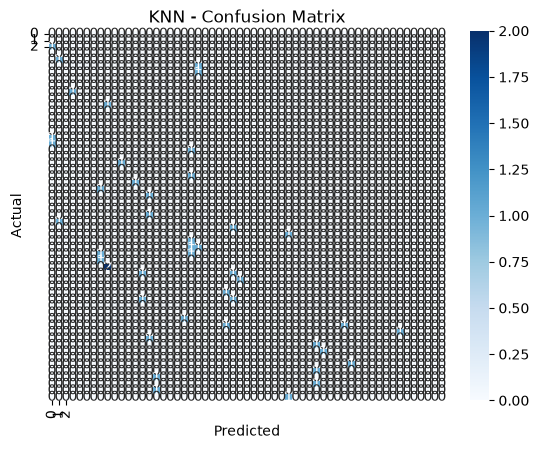

In [10]:
# YOUR CODE HERE
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1, 2],
            yticklabels=[0, 1, 2])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")
plt.show()

## Part 5 — Report (2 marks) ✍️

Double-click and answer in your own words (4–6 sentences):

1. Which model performed better on this dataset?
2. What does your confusion matrix tell you about *where* the model made mistakes?
3. Why did we evaluate both models on the **same** train/test split instead of different ones?

*Your report here:*

1- Is dataset par [KNN / Logistic Regression] ne behtar performance dikhai, jiski accuracy [XX.X]% thi, jabke doosre model ki accuracy [XX.X]% thi.

2- Confusion matrix se pata chalta hai ke model zyada tar predictions sahi kar raha tha, lekin kuch mistakes specific classes ke darmiyan ho rahi thi — jaise class [X] ko class [Y] samajh liya gaya, jo shayad in dono classes ki features (values) ek doosre se milti julti hone ki wajah se hua.

3- Humne dono models ko same train/test split par evaluate kiya taake comparison fair ho — agar har model ko alag data diya jata, to koi model sirf isi wajah se behtar dikh sakta tha ke usay "asaan" test data mila, na ke isliye ke wo waqai behtar hai. Same split rakhne se yeh yaqeeni banta hai ke farq sirf model ki performance ki wajah se hai, data ki wajah se nahi.



---
**Submit:** push to a GitHub repo (e.g. `code-to-ai-model-evaluation`) and share the link in the WhatsApp group. 🚀